Week 3 Kaggle Mini Project: Histopathic Cancer Detection




Backrground

The goal of this project is to solve a binary classification problem using convolutional neural networks. This data set comes from the Histopathologic Cancer Detection competition on Kaggle. In the data set are hundreds of thousands of RGB images of size 96x96 from pathology scans. Each image has a corresponing label (1:0) indicating if cancer was present.  

In [3]:
# Loading dependencies
import pandas as pd
import numpy as np
import keras
import matplotlib.pyplot as plt
from PIL import Image
import os

from keras.models import Sequential
from keras.layers import  Dense, Activation, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
import tensorflow as tf

/Users/jakebloom/Downloads/ISLP_labs-stable/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Exploratory Data Analysis

Let's look into more detail about the image structure and training set. Below we can see an example image, the total number of images, and the postitive/negative split. In total there are ~200k images of size 96x96x3 with ~40% of them being labeled as postive for cancer.

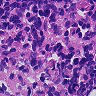

In [4]:
# Coding File Locs
X_train_folder = "/Users/jakebloom/cancer_hist/histopathologic-cancer-detection/train/"
X_test_folder = "/Users/jakebloom/cancer_hist/histopathologic-cancer-detection/test/"
train_labels = pd.read_csv("/Users/jakebloom/cancer_hist/histopathologic-cancer-detection/train_labels.csv")


train_labels.head()


# Let's load an image to see it
img = Image.open(X_train_folder+"/0a0a8bdf1d78af77dcc0b94aef6fb5c2f841a3c0.tif")
h, w = img.size
img

Image Dimensions (Height, Width):   ( 96 , 96 )
Training Image Count:  220025


Text(0.5, 1.0, 'Training Data: Positive vs Negative Cases')

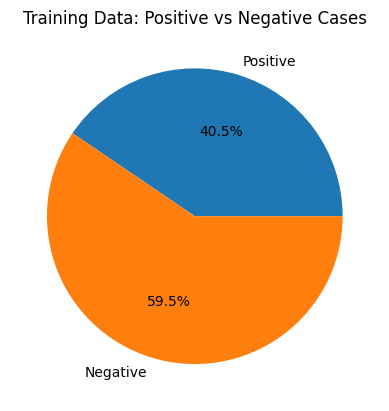

In [8]:
# And look at the image dimensions and number of images
print("Image Dimensions (Height, Width):  " , "(", h, "," , w, ")")
print("Training Image Count: ", len(train_labels))
pos_cases = train_labels.loc[train_labels['label'] == 1]
neg_cases = train_labels.loc[train_labels['label'] == 0]

case_labels = 'Positive', 'Negative'
sizes = [len(pos_cases), len(neg_cases)]
plt.pie(sizes, labels = case_labels,  autopct='%1.1f%%')
plt.title('Training Data: Positive vs Negative Cases')

In [42]:
#Function to read tif images to np array

def tif_to_numpy (file_path_name : str) -> np.array:
    img = Image.open(file_path_name)
    array = np.array(img).astype("float32") / 255.0
    return array



def my_generator(file_paths, labels, batch_size):
    while True: 
        for i in range(0, len(file_paths), batch_size):
            batch_paths = file_paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            batch_images = [tif_to_numpy(p) for p in batch_paths]
            X = np.stack(batch_images, axis=0)
            y = np.array(batch_labels)

            yield X, y

CNN Model Architecture

We are going to test a few different model architectures by changing a few different hyper parameters: kernel size, number of filters, number of layers. We will keep the backend architecture of the models the same: GlobalAveragePooling2D to a 256 Dense with 0.5 dropout to a sigmoid BinaryCrossEntropy classifier. The Adam optimizer will be used with a starting learning rate of 1e-4, a learning rate schedule of 1/2x after 3 attempts in val_loss and an early stopping after 4 epochs of worsening validation loss. 

Kernel Size:
For the first few models we will keep the architecture the same, but look at the effect of the kernel size

In [46]:
# Note: We are  reducing the training size here to keep the exploratory model training fast

#Building Model Framework for Size 3 Kernel
k3_model = Sequential()
k3_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
k3_model.add(MaxPooling2D((2,2)))
k3_model.add(BatchNormalization())
k3_model.add(Conv2D(8, (3,3), activation='relu'))
k3_model.add(MaxPooling2D((2,2)))
k3_model.add(BatchNormalization())
k3_model.add(GlobalAveragePooling2D())
k3_model.add(Dense(256, activation='relu'))
k3_model.add(Dropout(.5))
k3_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
k3_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
k3_model.summary()

#Size 5 Kernel
k5_model = Sequential()
k5_model.add(Conv2D(8, (5,5), activation='relu', input_shape=(h, w, 3)))
k5_model.add(MaxPooling2D((2,2)))
k5_model.add(BatchNormalization())
k5_model.add(Conv2D(8, (5,5), activation='relu'))
k5_model.add(MaxPooling2D((2,2)))
k5_model.add(BatchNormalization())
k5_model.add(GlobalAveragePooling2D())
k5_model.add(Dense(256, activation='relu'))
k5_model.add(Dropout(.5))
k5_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
k5_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
k5_model.summary()

#Size 11 Kernel
k11_model = Sequential()
k11_model.add(Conv2D(8, (11,11), activation='relu', input_shape=(h, w, 3)))
k11_model.add(MaxPooling2D((2,2)))
k11_model.add(BatchNormalization())
k11_model.add(Conv2D(8, (11,11), activation='relu'))
k11_model.add(MaxPooling2D((2,2)))
k11_model.add(BatchNormalization())
k11_model.add(GlobalAveragePooling2D())
k11_model.add(Dense(256, activation='relu'))
k11_model.add(Dropout(.5))
k11_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
k11_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
k11_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 47, 47, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 45, 45, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 22, 22, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 22, 22, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,433 (13.41 KB)

 Trainable params: 3,401 (13.29 KB)

 Non-trainable params: 32 (128.00 B)

...

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 86, 86, 8)      │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 43, 43, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 43, 43, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 33, 33, 8)      │         7,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,289 (51.91 KB)

 Trainable params: 13,257 (51.79 KB)

 Non-trainable params: 32 (128.00 B)

In [47]:
train_labels["file_names"] = train_labels["id"] + ".tif"
train_files = X_train_folder + train_labels["file_names"]
labels = train_labels["label"]
b_size = 64
train_size = 1920
val_size = int(train_size * 0.14)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=4, restore_best_weights=True)

# train_labels.head()

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
k3_hist = k3_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
k5_hist = k5_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
k11_hist = k11_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5207 - loss: 0.6989 - val_accuracy: 0.6250 - val_loss: 0.6849 - learning_rate: 1.0000e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5632 - loss: 0.6829 - val_accuracy: 0.6367 - val_loss: 0.6846 - learning_rate: 1.0000e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6057 - loss: 0.6603 - val_accuracy: 0.6094 - val_loss: 0.6912 - learning_rate: 1.0000e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6358 - loss: 0.6453 - val_accuracy: 0.3547 - val_loss: 0.7032 - learning_rate: 1.0000e-04
Epoch 5/20
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6510 - loss: 0.6342
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6516 - loss: 0.6339 - val_accuracy: 0.3750 - val_loss: 0.7142 - learning_rate: 1.0000e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6762 - los

Text(0.5, 0.98, 'Training Performance Metrics vs Kernel Size')

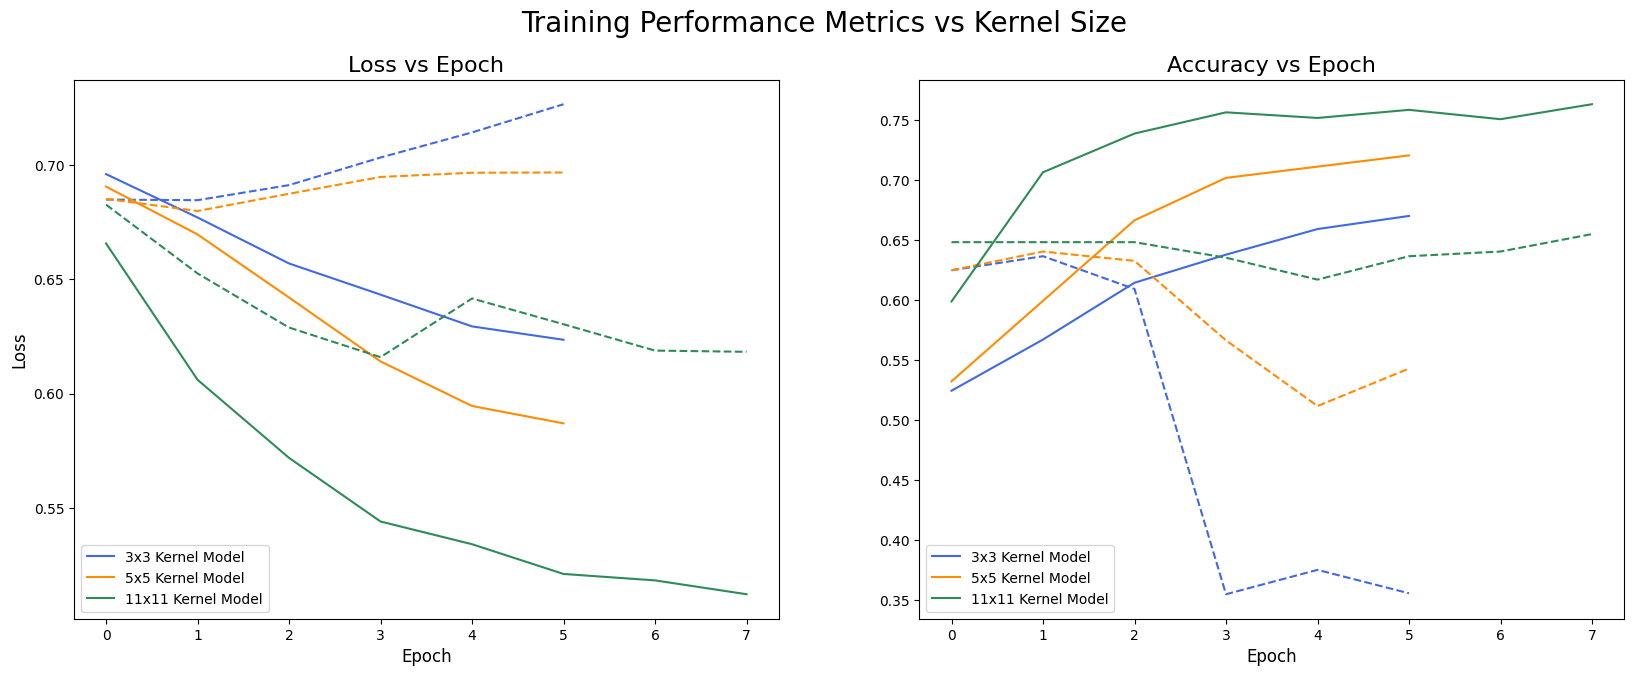

In [84]:
fig, ax = plt.subplots(1,2, figsize=(20,7))

ax[0].plot(k3_hist.history['val_loss'], color='royalblue', linestyle='--')
ax[0].plot(k3_hist.history['loss'], color='royalblue', label='3x3 Kernel Model')
ax[0].plot(k5_hist.history['val_loss'], color='darkorange', linestyle='--')
ax[0].plot(k5_hist.history['loss'], color='darkorange', label='5x5 Kernel Model')
ax[0].plot(k11_hist.history['val_loss'], color='seagreen', linestyle='--')
ax[0].plot(k11_hist.history['loss'], color='seagreen', label='11x11 Kernel Model')
ax[0].set_title('Loss vs Epoch', fontsize=16)
ax[0].legend(loc='lower left')
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_xlabel('Epoch', fontsize=12)

ax[1].plot(k3_hist.history['val_accuracy'], color='royalblue', linestyle='--')
ax[1].plot(k3_hist.history['accuracy'], color='royalblue', label='3x3 Kernel Model')
ax[1].plot(k5_hist.history['val_accuracy'], color='darkorange', linestyle='--')
ax[1].plot(k5_hist.history['accuracy'], color='darkorange', label='5x5 Kernel Model')
ax[1].plot(k11_hist.history['val_accuracy'], color='seagreen', linestyle='--')
ax[1].plot(k11_hist.history['accuracy'], color='seagreen', label='11x11 Kernel Model')
ax[1].set_title('Accuracy vs Epoch', fontsize=16)
ax[1].legend(loc='lower left')
ax[1].set_xlabel('Epoch', fontsize=12)

fig.suptitle('Training Performance Metrics vs Kernel Size', fontsize=20)

Here we see the best performing model was the largest kernel at 11x11. This is likely due to it capturing more information than the other models. We can get smaller kernel sizes to capture more info via more layers/filters. Moving forward we will stick with the 3x3 kernel even though at this few of layers and filters it appears to be overfitting.

Number of Filters:

Next we will keep the kernel size at 3x3, but change the number of filters per convolutional layer. We will test 3 different models again: 8, 16, and 128 filters per layer.

In [ ]:
# Note: We are  reducing the training size here to keep the exploratory model training fast


#Building Model Framework for Number of filters (3x3 kernel only)
f8_model = Sequential()
f8_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
f8_model.add(MaxPooling2D((2,2)))
f8_model.add(BatchNormalization())
f8_model.add(Conv2D(8, (3,3), activation='relu'))
f8_model.add(MaxPooling2D((2,2)))
f8_model.add(BatchNormalization())
f8_model.add(GlobalAveragePooling2D())
f8_model.add(Dense(256, activation='relu'))
f8_model.add(Dropout(.5))
f8_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
f8_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
f8_model.summary()

#16 Filters
f16_model = Sequential()
f16_model.add(Conv2D(16, (3,3), activation='relu', input_shape=(h, w, 3)))
f16_model.add(MaxPooling2D((2,2)))
f16_model.add(BatchNormalization())
f16_model.add(Conv2D(16, (3,3), activation='relu'))
f16_model.add(MaxPooling2D((2,2)))
f16_model.add(BatchNormalization())
f16_model.add(GlobalAveragePooling2D())
f16_model.add(Dense(256, activation='relu'))
f16_model.add(Dropout(.5))
f16_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
f16_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
f16_model.summary()

#128 Filters
f128_model = Sequential()
f128_model.add(Conv2D(128, (3,3), activation='relu', input_shape=(h, w, 3)))
f128_model.add(MaxPooling2D((2,2)))
f128_model.add(BatchNormalization())
f128_model.add(Conv2D(128, (3,3), activation='relu'))
f128_model.add(MaxPooling2D((2,2)))
f128_model.add(BatchNormalization())
f128_model.add(GlobalAveragePooling2D())
f128_model.add(Dense(256, activation='relu'))
f128_model.add(Dropout(.5))
f128_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
f128_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
f128_model.summary()

/Users/jakebloom/Downloads/ISLP_labs-stable/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 47, 47, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 45, 45, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 22, 22, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 22, 22, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,433 (13.41 KB)

 Trainable params: 3,401 (13.29 KB)

...

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 94, 94, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 47, 47, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 22, 22, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,473 (724.50 KB)

 Trainable params: 184,961 (722.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [86]:
train_labels["file_names"] = train_labels["id"] + ".tif"
train_files = X_train_folder + train_labels["file_names"]
labels = train_labels["label"]
b_size = 64
train_size = 1920
val_size = int(train_size * 0.14)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=4, restore_best_weights=True)

# train_labels.head()

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
f8_hist = f8_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
f16_hist = f16_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
f128_hist = f128_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5661 - loss: 0.6813 - val_accuracy: 0.6250 - val_loss: 0.6879 - learning_rate: 1.0000e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5982 - loss: 0.6772 - val_accuracy: 0.6445 - val_loss: 0.6840 - learning_rate: 1.0000e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5891 - loss: 0.6710 - val_accuracy: 0.6484 - val_loss: 0.6813 - learning_rate: 1.0000e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6158 - loss: 0.6571 - val_accuracy: 0.6453 - val_loss: 0.6796 - learning_rate: 1.0000e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6464 - loss: 0.6404 - val_accuracy: 0.6289 - val_loss: 0.6753 - learning_rate: 1.0000e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6662 - loss: 0.6344 - val_accuracy: 0.6523 - val_loss: 0.6668 - learning_rate: 1.0000e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6779 

Text(0.5, 0.98, 'Training Performance Metrics vs Number of Filters')

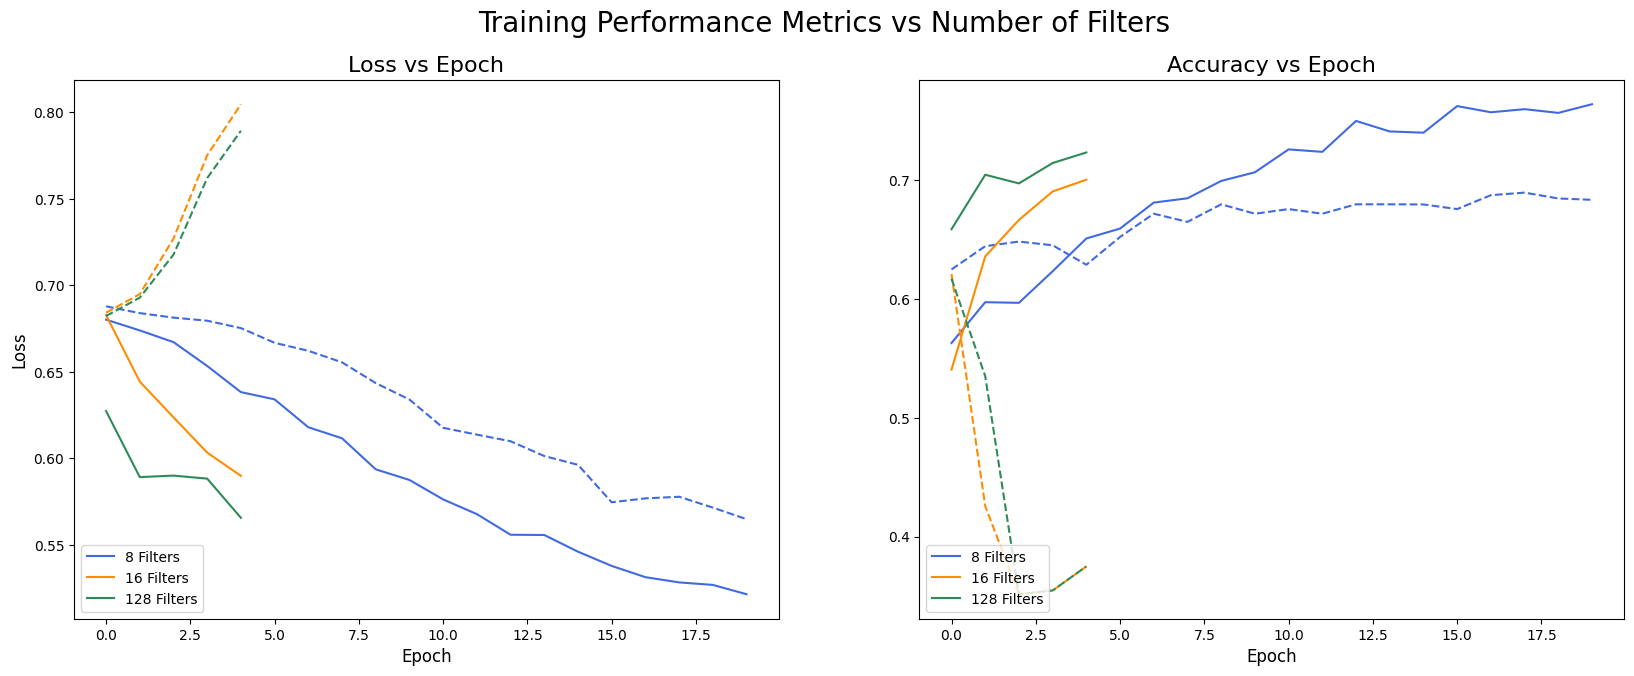

In [94]:
fig, ax = plt.subplots(1,2, figsize=(20,7))

ax[0].plot(f8_hist.history['val_loss'], color='royalblue', linestyle='--')
ax[0].plot(f8_hist.history['loss'], color='royalblue', label='8 Filters')
ax[0].plot(f16_hist.history['val_loss'], color='darkorange', linestyle='--')
ax[0].plot(f16_hist.history['loss'], color='darkorange', label='16 Filters')
ax[0].plot(f128_hist.history['val_loss'], color='seagreen', linestyle='--')
ax[0].plot(f128_hist.history['loss'], color='seagreen', label='128 Filters')
ax[0].set_title('Loss vs Epoch', fontsize=16)
ax[0].legend(loc='lower left')
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_xlabel('Epoch', fontsize=12)

ax[1].plot(f8_hist.history['val_accuracy'], color='royalblue', linestyle='--')
ax[1].plot(f8_hist.history['accuracy'], color='royalblue', label='8 Filters')
ax[1].plot(f16_hist.history['val_accuracy'], color='darkorange', linestyle='--')
ax[1].plot(f16_hist.history['accuracy'], color='darkorange', label='16 Filters')
ax[1].plot(f128_hist.history['val_accuracy'], color='seagreen', linestyle='--')
ax[1].plot(f128_hist.history['accuracy'], color='seagreen', label='128 Filters')
ax[1].set_title('Accuracy vs Epoch', fontsize=16)
ax[1].legend(loc='lower left')
ax[1].set_xlabel('Epoch', fontsize=12)

fig.suptitle('Training Performance Metrics vs Number of Filters', fontsize=20)

Here we see a great example of exploding loss in the 16 and 128 filter models. This is likely due to there being too many parameters without enough normalization/regularization as well as potentially a bad learning rate. Either way this is telling us that more filters might not be best for this particular task.

Number of Layers:
For the last hyperparameter we will change the number of convolutional layers. Here we will test 1, 3,and 6 layer models.

In [ ]:
# Note: We are  reducing the training size here to keep the exploratory model training fast


#Building Model Framework for Number of Layers (3x3 kernel, 8 filters only)
l1_model = Sequential()
l1_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
l1_model.add(MaxPooling2D((2,2)))
l1_model.add(BatchNormalization())
l1_model.add(GlobalAveragePooling2D())
l1_model.add(Dense(256, activation='relu'))
l1_model.add(Dropout(.5))
l1_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l1_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l1_model.summary()

#3 Layers Kernel
l3_model = Sequential()
l3_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
l3_model.add(Conv2D(8, (3,3), activation='relu'))
l3_model.add(Conv2D(8, (3,3), activation='relu'))
l3_model.add(MaxPooling2D((2,2)))
l3_model.add(BatchNormalization())
l3_model.add(GlobalAveragePooling2D())
l3_model.add(Dense(256, activation='relu'))
l3_model.add(Dropout(.5))
l3_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l3_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l3_model.summary()

#6 Layers
l6_model = Sequential()
l6_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
l6_model.add(Conv2D(8, (3,3), activation='relu'))
l6_model.add(Conv2D(8, (3,3), activation='relu'))
l6_model.add(Conv2D(8, (3,3), activation='relu'))
l6_model.add(Conv2D(8, (3,3), activation='relu'))
l6_model.add(Conv2D(8, (3,3), activation='relu'))
l6_model.add(MaxPooling2D((2,2)))
l6_model.add(BatchNormalization())
l6_model.add(GlobalAveragePooling2D())
l6_model.add(Dense(256, activation='relu'))
l6_model.add(Dropout(.5))
l6_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l6_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l6_model.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_44 (Conv2D)              │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 47, 47, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 16 (64.00 B)

...

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 92, 92, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 90, 90, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 88, 88, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 86, 86, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 84, 84, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 42, 42, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 42, 42, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,737 (22.41 KB)

 Trainable params: 5,721 (22.35 KB)

 Non-trainable params: 16 (64.00 B)

In [92]:
train_labels["file_names"] = train_labels["id"] + ".tif"
train_files = X_train_folder + train_labels["file_names"]
labels = train_labels["label"]
b_size = 64
train_size = 1920
val_size = int(train_size * 0.14)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=4, restore_best_weights=True)

# train_labels.head()

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l1_hist = l1_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l3_hist = l3_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l6_hist = l6_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4887 - loss: 0.6991 - val_accuracy: 0.5469 - val_loss: 0.6911 - learning_rate: 1.0000e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5408 - loss: 0.6859 - val_accuracy: 0.6445 - val_loss: 0.6874 - learning_rate: 1.0000e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5566 - loss: 0.6834 - val_accuracy: 0.6484 - val_loss: 0.6837 - learning_rate: 1.0000e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5758 - loss: 0.6737 - val_accuracy: 0.6453 - val_loss: 0.6796 - learning_rate: 1.0000e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5929 - loss: 0.6714 - val_accuracy: 0.6355 - val_loss: 0.6761 - learning_rate: 1.0000e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6244 - loss: 0.6576 - val_accuracy: 0.6250 - val_loss: 0.6732 - learning_rate: 1.0000e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6307 

Text(0.5, 0.98, 'Training Performance Metrics vs Number of Layers')

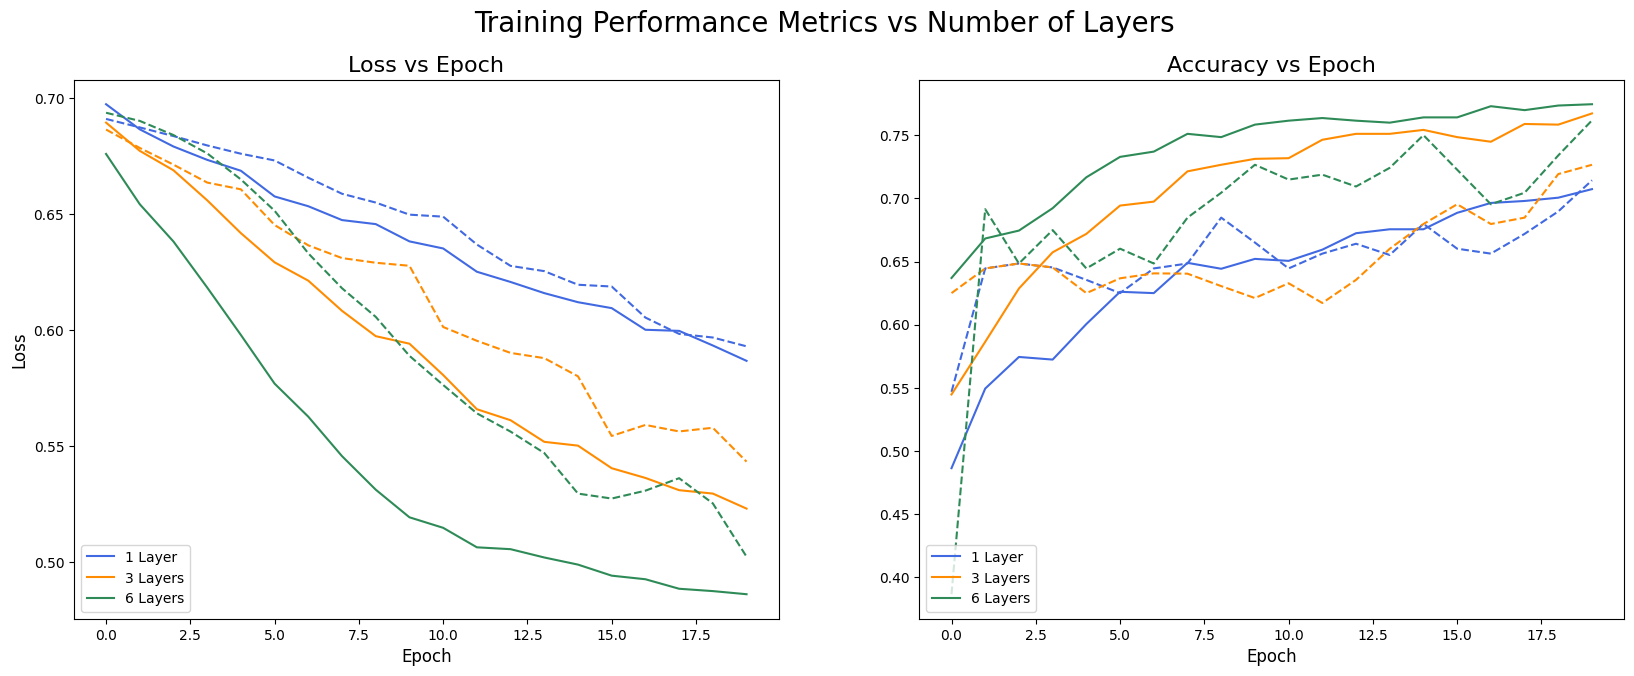

In [95]:
fig, ax = plt.subplots(1,2, figsize=(20,7))

ax[0].plot(l1_hist.history['val_loss'], color='royalblue', linestyle='--')
ax[0].plot(l1_hist.history['loss'], color='royalblue', label='1 Layer')
ax[0].plot(l3_hist.history['val_loss'], color='darkorange', linestyle='--')
ax[0].plot(l3_hist.history['loss'], color='darkorange', label='3 Layers')
ax[0].plot(l6_hist.history['val_loss'], color='seagreen', linestyle='--')
ax[0].plot(l6_hist.history['loss'], color='seagreen', label='6 Layers')
ax[0].set_title('Loss vs Epoch', fontsize=16)
ax[0].legend(loc='lower left')
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_xlabel('Epoch', fontsize=12)

ax[1].plot(l1_hist.history['val_accuracy'], color='royalblue', linestyle='--')
ax[1].plot(l1_hist.history['accuracy'], color='royalblue', label='1 Layer')
ax[1].plot(l3_hist.history['val_accuracy'], color='darkorange', linestyle='--')
ax[1].plot(l3_hist.history['accuracy'], color='darkorange', label='3 Layers')
ax[1].plot(l6_hist.history['val_accuracy'], color='seagreen', linestyle='--')
ax[1].plot(l6_hist.history['accuracy'], color='seagreen', label='6 Layers')
ax[1].set_title('Accuracy vs Epoch', fontsize=16)
ax[1].legend(loc='lower left')
ax[1].set_xlabel('Epoch', fontsize=12)

fig.suptitle('Training Performance Metrics vs Number of Layers', fontsize=20)


This is a great example of deeper learning being better. As we add more layers we seee a better performance in accuracy and loss. For the final round of models we will be sure to use many layers. Below we will build 3 models: one with kernel size = (3,3) and many layers, our kernel size decreasing from  (11,11) to (3,3), and one where we increase the  number of filters per layer.

In [98]:
#3x3 6 CONV, maxpooling until out of Layers
l_many_model = Sequential()
l_many_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(MaxPooling2D((2,2)))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(MaxPooling2D((2,2)))
l_many_model.add(BatchNormalization())
l_many_model.add(GlobalAveragePooling2D())
l_many_model.add(Dense(256, activation='relu'))
l_many_model.add(Dropout(.5))
l_many_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l_many_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l_many_model.summary()


#Descending Kernel Size
l_desc_model = Sequential()
l_desc_model.add(Conv2D(8, (11,11), activation='relu', input_shape=(h, w, 3)))
l_desc_model.add(Conv2D(8, (11,11), activation='relu'))
l_desc_model.add(Conv2D(8, (11,11), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(BatchNormalization())
l_desc_model.add(GlobalAveragePooling2D())
l_desc_model.add(Dense(256, activation='relu'))
l_desc_model.add(Dropout(.5))
l_desc_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l_desc_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l_desc_model.summary()


#Increasing Filter Size
l_exp_model = Sequential()
l_exp_model.add(Conv2D(2, (3,3), activation='relu', input_shape=(h, w, 3)))
l_exp_model.add(Conv2D(4, (3,3), activation='relu'))
l_exp_model.add(Conv2D(8, (3,3), activation='relu'))
l_exp_model.add(MaxPooling2D((2,2)))
l_exp_model.add(Conv2D(16, (3,3), activation='relu'))
l_exp_model.add(Conv2D(32, (3,3), activation='relu'))
l_exp_model.add(Conv2D(64, (3,3), activation='relu'))
l_exp_model.add(MaxPooling2D((2,2)))
l_exp_model.add(Conv2D(128, (3,3), activation='relu'))
l_exp_model.add(Conv2D(256, (3,3), activation='relu'))
l_exp_model.add(Conv2D(512, (3,3), activation='relu'))
l_exp_model.add(MaxPooling2D((2,2)))
l_exp_model.add(Conv2D(1024, (3,3), activation='relu'))
l_exp_model.add(BatchNormalization())
l_exp_model.add(GlobalAveragePooling2D())
l_exp_model.add(Dense(256, activation='relu'))
l_exp_model.add(Dropout(.5))
l_exp_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l_exp_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
l_exp_model.summary()

Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_87 (Conv2D)              │ (None, 94, 94, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 92, 92, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 90, 90, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 88, 88, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 86, 86, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 84, 84, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 42, 42, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 40, 40, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 38, 38, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 36, 36, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 34, 34, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 30, 30, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 15, 15, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 15, 15, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_18     │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,241 (36.10 KB)

 Trainable params: 9,225 (36.04 KB)

 Non-trainable params: 16 (64.00 B)

...

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_108 (Conv2D)             │ (None, 94, 94, 2)      │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_109 (Conv2D)             │ (None, 92, 92, 4)      │            76 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_110 (Conv2D)             │ (None, 90, 90, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 45, 45, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_111 (Conv2D)             │ (None, 43, 43, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_112 (Conv2D)             │ (None, 41, 41, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_113 (Conv2D)             │ (None, 39, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_114 (Conv2D)             │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 13, 13, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_117 (Conv2D)             │ (None, 4, 4, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 4, 4, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_20     │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,560,285 (25.03 MB)

 Trainable params: 6,558,237 (25.02 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [99]:
train_labels["file_names"] = train_labels["id"] + ".tif"
train_files = X_train_folder + train_labels["file_names"]
labels = train_labels["label"]
b_size = 64
train_size = 1920
val_size = int(train_size * 0.14)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=4, restore_best_weights=True)

# train_labels.head()

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l_many_hist = l_many_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l_desc_hist = l_desc_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l_exp_hist = l_exp_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.5304 - loss: 0.6909 - val_accuracy: 0.6250 - val_loss: 0.6884 - learning_rate: 1.0000e-04
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6153 - loss: 0.6801 - val_accuracy: 0.6445 - val_loss: 0.6812 - learning_rate: 1.0000e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6527 - loss: 0.6568 - val_accuracy: 0.6484 - val_loss: 0.6724 - learning_rate: 1.0000e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7098 - loss: 0.6170 - val_accuracy: 0.6453 - val_loss: 0.6626 - learning_rate: 1.0000e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7316 - loss: 0.5898 - val_accuracy: 0.6250 - val_loss: 0.6492 - learning_rate: 1.0000e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7423 - loss: 0.5651 - val_accuracy: 0.6445 - val_loss: 0.6312 - learning_rate: 1.0000e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7333 

Text(0.5, 0.98, 'Training Performance Metrics vs Various Changes')

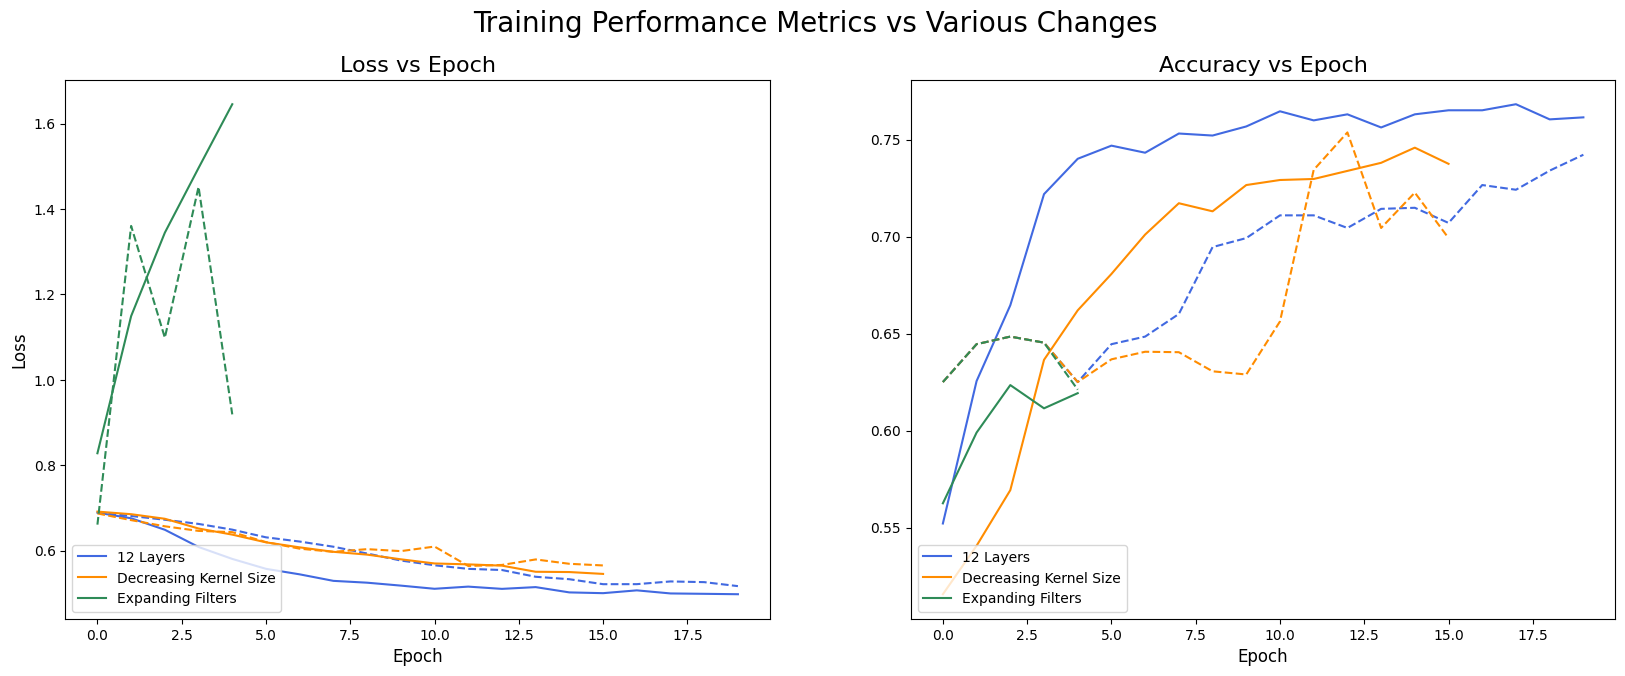

In [109]:
fig, ax = plt.subplots(1,2, figsize=(20,7))

ax[0].plot(l_many_hist.history['val_loss'], color='royalblue', linestyle='--')
ax[0].plot(l_many_hist.history['loss'], color='royalblue', label='12 Layers')
ax[0].plot(l_desc_hist.history['val_loss'], color='darkorange', linestyle='--')
ax[0].plot(l_desc_hist.history['loss'], color='darkorange', label='Decreasing Kernel Size')
ax[0].plot(l_exp_hist.history['val_loss'], color='seagreen', linestyle='--')
ax[0].plot(l_exp_hist.history['loss'], color='seagreen', label='Expanding Filters')
ax[0].set_title('Loss vs Epoch', fontsize=16)
ax[0].legend(loc='lower left')
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_xlabel('Epoch', fontsize=12)

ax[1].plot(l_many_hist.history['val_accuracy'], color='royalblue', linestyle='--')
ax[1].plot(l_many_hist.history['accuracy'], color='royalblue', label='12 Layers')
ax[1].plot(l_desc_hist.history['val_accuracy'], color='darkorange', linestyle='--')
ax[1].plot(l_desc_hist.history['accuracy'], color='darkorange', label='Decreasing Kernel Size')
ax[1].plot(l_exp_hist.history['val_accuracy'], color='seagreen', linestyle='--')
ax[1].plot(l_exp_hist.history['accuracy'], color='seagreen', label='Expanding Filters')
ax[1].set_title('Accuracy vs Epoch', fontsize=16)
ax[1].legend(loc='lower left')
ax[1].set_xlabel('Epoch', fontsize=12)

fig.suptitle('Training Performance Metrics vs Various Changes', fontsize=20)


Here we see exploding loss with the number of filters, but good performance on the other models. Let's test those along with the shallow kernel size = (11,11) from earlier on a larger chunk of the data.

In [111]:
#Size 11 Kernel
k11_model = Sequential()
k11_model.add(Conv2D(8, (11,11), activation='relu', input_shape=(h, w, 3)))
k11_model.add(MaxPooling2D((2,2)))
k11_model.add(BatchNormalization())
k11_model.add(Conv2D(8, (11,11), activation='relu'))
k11_model.add(MaxPooling2D((2,2)))
k11_model.add(BatchNormalization())
k11_model.add(GlobalAveragePooling2D())
k11_model.add(Dense(256, activation='relu'))
k11_model.add(Dropout(.5))
k11_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
k11_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )
k11_model.summary()

#3x3 6 CONV, maxpooling until out of Layers
l_many_model = Sequential()
l_many_model.add(Conv2D(8, (3,3), activation='relu', input_shape=(h, w, 3)))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(MaxPooling2D((2,2)))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(Conv2D(8, (3,3), activation='relu'))
l_many_model.add(MaxPooling2D((2,2)))
l_many_model.add(BatchNormalization())
l_many_model.add(GlobalAveragePooling2D())
l_many_model.add(Dense(256, activation='relu'))
l_many_model.add(Dropout(.5))
l_many_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l_many_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )


#Descending Kernel Size
l_desc_model = Sequential()
l_desc_model.add(Conv2D(8, (11,11), activation='relu', input_shape=(h, w, 3)))
l_desc_model.add(Conv2D(8, (11,11), activation='relu'))
l_desc_model.add(Conv2D(8, (11,11), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(Conv2D(8, (5,5), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(Conv2D(8, (3,3), activation='relu'))
l_desc_model.add(MaxPooling2D((2,2)))
l_desc_model.add(BatchNormalization())
l_desc_model.add(GlobalAveragePooling2D())
l_desc_model.add(Dense(256, activation='relu'))
l_desc_model.add(Dropout(.5))
l_desc_model.add(Dense(1, activation='sigmoid'))
loss_fn = keras.losses.BinaryCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=1e-4)
l_desc_model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'] )



train_labels["file_names"] = train_labels["id"] + ".tif"
train_files = X_train_folder + train_labels["file_names"]
labels = train_labels["label"]
b_size = 64
train_size = 192000
val_size = int(train_size * 0.14)

lr_schedule = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss",patience=4, restore_best_weights=True)

# train_labels.head()

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l_many_hist = l_many_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
l_desc_hist = l_desc_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

train_gen = my_generator(train_files[0:train_size], labels[0:train_size], batch_size=b_size)
val_gen   = my_generator(train_files[train_size+1:train_size+val_size], labels[train_size+1:train_size+val_size], batch_size=b_size)
k11_hist = k11_model.fit(train_gen, 
            steps_per_epoch=len(labels[0:train_size])//b_size, 
            epochs=20,
            validation_data=val_gen,
            validation_steps=(val_size + 1)//b_size,
            callbacks=[lr_schedule, early_stop])

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_169 (Conv2D)             │ (None, 86, 86, 8)      │         2,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 43, 43, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 43, 43, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_170 (Conv2D)             │ (None, 33, 33, 8)      │         7,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 16, 16, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_25     │ (None, 8)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 256)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,289 (51.91 KB)

 Trainable params: 13,257 (51.79 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 122s 39ms/step - accuracy: 0.7522 - loss: 0.5205 - val_accuracy: 0.7941 - val_loss: 0.4555 - learning_rate: 1.0000e-04
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 116s 39ms/step - accuracy: 0.7784 - loss: 0.4841 - val_accuracy: 0.7877 - val_loss: 0.4685 - learning_rate: 1.0000e-04
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 116s 39ms/step - accuracy: 0.7987 - loss: 0.4499 - val_accuracy: 0.8221 - val_loss: 0.4016 - learning_rate: 1.0000e-04
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 111s 37ms/step - accuracy: 0.8174 - loss: 0.4160 - val_accuracy: 0.8236 - val_loss: 0.4045 - learning_rate: 1.0000e-04
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 109s 36ms/step - accuracy: 0.8287 - loss: 0.3970 - val_accuracy: 0.8176 - val_loss: 0.4260 - learning_rate: 1.0000e-04
Epoch 6/20
2999/3000 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8359 - loss: 0.3827
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
3000/3000 ━━━━━━━━━━━━━━━━━━━━

Text(0.5, 0.98, 'Training Performance Metrics vs Various Changes')

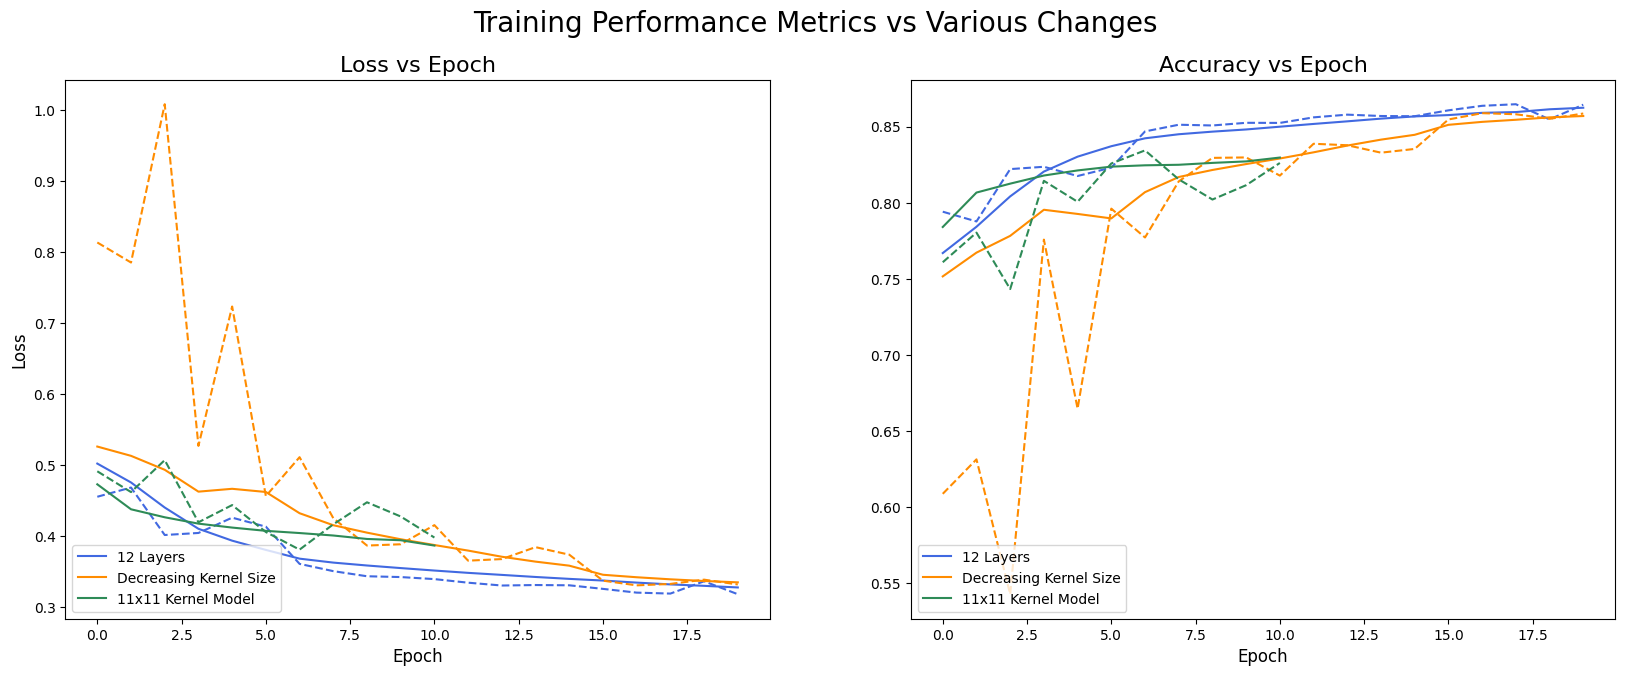

In [113]:
fig, ax = plt.subplots(1,2, figsize=(20,7))

ax[0].plot(l_many_hist.history['val_loss'], color='royalblue', linestyle='--')
ax[0].plot(l_many_hist.history['loss'], color='royalblue', label='12 Layers')
ax[0].plot(l_desc_hist.history['val_loss'], color='darkorange', linestyle='--')
ax[0].plot(l_desc_hist.history['loss'], color='darkorange', label='Decreasing Kernel Size')
ax[0].plot(k11_hist.history['val_loss'], color='seagreen', linestyle='--')
ax[0].plot(k11_hist.history['loss'], color='seagreen', label='11x11 Kernel Model')
ax[0].set_title('Loss vs Epoch', fontsize=16)
ax[0].legend(loc='lower left')
ax[0].set_ylabel('Loss', fontsize=12)
ax[0].set_xlabel('Epoch', fontsize=12)

ax[1].plot(l_many_hist.history['val_accuracy'], color='royalblue', linestyle='--')
ax[1].plot(l_many_hist.history['accuracy'], color='royalblue', label='12 Layers')
ax[1].plot(l_desc_hist.history['val_accuracy'], color='darkorange', linestyle='--')
ax[1].plot(l_desc_hist.history['accuracy'], color='darkorange', label='Decreasing Kernel Size')
ax[1].plot(k11_hist.history['val_accuracy'], color='seagreen', linestyle='--')
ax[1].plot(k11_hist.history['accuracy'], color='seagreen', label='11x11 Kernel Model')
ax[1].set_title('Accuracy vs Epoch', fontsize=16)
ax[1].legend(loc='lower left')
ax[1].set_xlabel('Epoch', fontsize=12)

fig.suptitle('Training Performance Metrics vs Various Changes', fontsize=20)

Results and Analysis

All three of these models are appproaching similar levels of accuracy and loss with the 12 layer model having the lowest loss and highest accuracy. To improve further we could try to get more layers, but maybe the models can be used together. Let's look to see if the models are missing on similar validation data or if we can improve model predictions through an ensemble:

We'll try to see how the three models vote on the image classificaiton. We'll take their predicitons and average them to see if there is any improvement.

In [125]:
val_gen = my_generator(train_files, labels, batch_size=b_size)
k11_predict = k11_model.predict(val_gen, steps=len(labels)//b_size)

val_gen = my_generator(train_files, labels, batch_size=b_size)
l_many_predict = l_many_model.predict(val_gen, steps=len(labels)//b_size)

val_gen = my_generator(train_files, labels, batch_size=b_size)
l_desc_predict = l_desc_model.predict(val_gen, steps=len(labels)//b_size)

# consensus_predict = ( (k11_predict + l_many_predict + l_desc_predict) / 3 > 0.5).astype(int) 


3437/3437 ━━━━━━━━━━━━━━━━━━━━ 111s 32ms/step
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 109s 32ms/step
3437/3437 ━━━━━━━━━━━━━━━━━━━━ 112s 33ms/step


In [135]:
consensus_predict = ( (k11_predict + l_many_predict + l_desc_predict) / 3 > 0.5).astype(int) 

def make_binary_labels(predictions):
    return (predictions >= 0.5).astype(int)

k11_ = make_binary_labels(k11_predict)
l_many_ = make_binary_labels(l_many_predict)
l_desc_ = make_binary_labels(l_desc_predict)
# consensus_ = make_binary_labels(consensus_predict)
post_consensus =  ( (k11_+ l_many_ + l_desc_) / 3 > 0.5).astype(int) 

In [139]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_true = np.array(labels[:len(labels)//b_size * b_size]) 
print("K11 Accuracy:", accuracy_score(y_true, k11_))
print("L_Many Accuracy:", accuracy_score(y_true, l_many_))
print("L_Desc Accuracy:", accuracy_score(y_true, l_desc_))
print("Ensemble Accuracy:", accuracy_score(y_true, consensus_predict))
print("Rounded Ensemble Accuracy:", accuracy_score(y_true, post_consensus ))


print("\n\nEnsemble F1:", f1_score(y_true, l_many_))
print("Ensemble AUC:", roc_auc_score(y_true, l_many_)) 



K11 Accuracy: 0.8345122926971196
L_Many Accuracy: 0.8648530695373873
L_Desc Accuracy: 0.8583066627873145
Ensemble Accuracy: 0.8669579211521676
Rounded Ensemble Accuracy: 0.8611843540878673


Ensemble F1: 0.8178609940201941
Ensemble AUC: 0.8463844598115403


In [140]:
test_files = [os.path.join(X_test_folder, fname) for fname in os.listdir(X_test_folder) if fname.endswith(".tif")]
test_files.sort()

def load_images(file_paths):
    imgs = [tif_to_numpy(fp) for fp in file_paths]
    return np.stack(imgs, axis=0)

X_test = load_images(test_files)

test_preds = l_many_model.predict(X_test, batch_size=64).ravel()
test_labels = (test_preds >= 0.5).astype(int) 

898/898 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step


In [1]:
ids = [os.path.splitext(os.path.basename(fp))[0] for fp in test_files]

kaggle_histopathologic_submission = pd.DataFrame({
    "id": ids,
    "label": test_labels})

kaggle_histopathologic_submission .to_csv("kaggle_histopathologic_submission.csv", index=False)

NameError: name 'test_files' is not defined

Conclusion

Keeping dropout rate and backend NN architecture the same we saw the following results in changing other hyperparameters:


Kernel size:
Increasing kernel size boosted model performance in both loss and accuracy in a shallow (2 convolutional layer) structure.

Filter size:
Increasing filters while keeping kernel size and layer depth the same increased the loss and decreased accuracy. This is likely due to increasing relative model complexity without changing parameters like dropout or batch normalization. This lead to overfitting in the model.

Layer Depth:
Increasing layer depth resulted in a better performing model. As discussed in class increasing the convolutional layer depth generally tends to increase computer vision model accuracy.

Ensembling:
Not much was gained in the accuracy of the ensemble method. This likely implies that the models are missing on similar image values. Since the gain in accuracy is less than 1% it makes more sense to keep the model to just the 12 convolutional layer one.



For future iterations having more layers, alternate pooling structure, and different backend architecture should be explored. The 